<a href="https://colab.research.google.com/github/AIVIETNAM-AIO-HUYTRUONG/AIO/blob/aio/M4-Foundation-DL/Optimization/W1/Linear%20Regression/advertising_stochastic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!wget -q \
    "https://raw.githubusercontent.com/AIVIETNAM-AIO-HUYTRUONG/AIO/refs/heads/aio/helpers/dataset_helper.py" \
    -O /content/helper.py

%run /content/helper.py

<Figure size 640x480 with 0 Axes>

In [ ]:
# https://raw.githubusercontent.com/AIVIETNAM-AIO-HUYTRUONG/AIO/refs/heads/aio/M4-Foundation-DL/Optimization/Data/advertising.csv
CSV_URL = input("Paste CSV URL: ").strip()

load_csv_with_numpy(
    url=CSV_URL,
    data_dir="/content/data",
    filename="advertising.csv"
)

Paste CSV URL: https://raw.githubusercontent.com/AIVIETNAM-AIO-HUYTRUONG/AIO/refs/heads/aio/M4-Foundation-DL/Optimization/Data/advertising.csv
Using existing dataset:
/content/data/advertising.csv
Dataset loaded successfully:
- Path: /content/data/advertising.csv
- Rows: 201
- Columns: 4


array([[  nan,   nan,   nan,   nan],
       [230.1,  37.8,  69.2,  22.1],
       [ 44.5,  39.3,  45.1,  10.4],
       [ 17.2,  45.9,  69.3,  12. ],
       [151.5,  41.3,  58.5,  16.5],
       [180.8,  10.8,  58.4,  17.9],
       [  8.7,  48.9,  75. ,   7.2],
       [ 57.5,  32.8,  23.5,  11.8],
       [120.2,  19.6,  11.6,  13.2],
       [  8.6,   2.1,   1. ,   4.8],
       [199.8,   2.6,  21.2,  15.6],
       [ 66.1,   5.8,  24.2,  12.6],
       [214.7,  24. ,   4. ,  17.4],
       [ 23.8,  35.1,  65.9,   9.2],
       [ 97.5,   7.6,   7.2,  13.7],
       [204.1,  32.9,  46. ,  19. ],
       [195.4,  47.7,  52.9,  22.4],
       [ 67.8,  36.6, 114. ,  12.5],
       [281.4,  39.6,  55.8,  24.4],
       [ 69.2,  20.5,  18.3,  11.3],
       [147.3,  23.9,  19.1,  14.6],
       [218.4,  27.7,  53.4,  18. ],
       [237.4,   5.1,  23.5,  17.5],
       [ 13.2,  15.9,  49.6,   5.6],
       [228.3,  16.9,  26.2,  20.5],
       [ 62.3,  12.6,  18.3,   9.7],
       [262.9,   3.5,  19.5,  17. ],
 

### **Nạp và tiền xử lý dữ liệu (Data Loading & Preprocessing)**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Đọc dữ liệu từ file CSV, phân tách bởi dấu phẩy ','
data = np.genfromtxt('/content/data/advertising.csv', delimiter=',', skip_header= 1)
print(f"data shape: {data.shape}")
print(f"data: \n{data}")

data shape: (200, 4)
data: 
[[230.1  37.8  69.2  22.1]
 [ 44.5  39.3  45.1  10.4]
 [ 17.2  45.9  69.3  12. ]
 [151.5  41.3  58.5  16.5]
 [180.8  10.8  58.4  17.9]
 [  8.7  48.9  75.    7.2]
 [ 57.5  32.8  23.5  11.8]
 [120.2  19.6  11.6  13.2]
 [  8.6   2.1   1.    4.8]
 [199.8   2.6  21.2  15.6]
 [ 66.1   5.8  24.2  12.6]
 [214.7  24.    4.   17.4]
 [ 23.8  35.1  65.9   9.2]
 [ 97.5   7.6   7.2  13.7]
 [204.1  32.9  46.   19. ]
 [195.4  47.7  52.9  22.4]
 [ 67.8  36.6 114.   12.5]
 [281.4  39.6  55.8  24.4]
 [ 69.2  20.5  18.3  11.3]
 [147.3  23.9  19.1  14.6]
 [218.4  27.7  53.4  18. ]
 [237.4   5.1  23.5  17.5]
 [ 13.2  15.9  49.6   5.6]
 [228.3  16.9  26.2  20.5]
 [ 62.3  12.6  18.3   9.7]
 [262.9   3.5  19.5  17. ]
 [142.9  29.3  12.6  15. ]
 [240.1  16.7  22.9  20.9]
 [248.8  27.1  22.9  18.9]
 [ 70.6  16.   40.8  10.5]
 [292.9  28.3  43.2  21.4]
 [112.9  17.4  38.6  11.9]
 [ 97.2   1.5  30.   13.2]
 [265.6  20.    0.3  17.4]
 [ 95.7   1.4   7.4  11.9]
 [290.7   4.1   8.5  17.8]


- `np.genfromtxt(..., skip_header=1)`: Đọc file CSV chứa dữ liệu. Lệnh `skip_header=1` bỏ qua dòng tiêu đề đầu tiên (tv, radio, newspaper, sales) để tránh bị lỗi giá trị khuyết `nan`.
- `N = data.shape[0]`: Lấy tổng số lượng mẫu (số dòng) trong tập dữ liệu.
- `Slicing (data[:, i])`: Tách dữ liệu thành 4 mảng 1D riêng biệt tương ứng với các biến đầu vào $x_1$ (TV), $x_2$ (Radio), $x_3$ (Newspaper) và biến mục tiêu $y$ (Sales).

In [ ]:
N = data.shape[0]

tv_data = data[:,0]
radio_data = data[:,1]
newspaper_data = data[:,2]
sales_data = data[:,3]

print(f"tv_data shape: {tv_data.shape}")
print(f"radio_data shape: {radio_data.shape}")
print(f"newspaper_data shape: {newspaper_data.shape}")
print(f"sales_data shape: {sales_data.shape}")

tv_data shape: (200,)
radio_data shape: (200,)
newspaper_data shape: (200,)
sales_data shape: (200,)


### **Định nghĩa các hàm cốt lõi của mô hình (Core Functions)**
- Hàm dự đoán (Forward Pass) theo phương trình hồi quy tuyến tính bội:
$$\hat{y} = w_1 x_1 + w_2 x_2 + w_3 x_3 + b$$

- Tính độ lỗi (Squared Error / MSE) cho một điểm dữ liệu đơn lẻ:
$$Loss = (\hat{y} - y)^2$$

- Tính đạo hàm riêng (Gradient) của hàm $Loss$ theo từng trọng số $w_i$ và bias $b$:   
  - $\frac{\partial Loss}{\partial w_i} = 2 \cdot x_i \cdot (\hat{y} - y)$
  -  $\frac{\partial Loss}{\partial b} = 2 \cdot (\hat{y} - y)$

- Cập nhật tham số theo thuật toán Gradient Descent với tốc độ học lr (Learning Rate):   
$$w_{i\_mới} = w_i - \eta \cdot \frac{\partial Loss}{\partial w_i}$$

In [ ]:
def predict(x1, x2, x3, w1, w2, w3, b):
    return w1*x1 + w2*x2 + w3*x3 + b

def compute_loss(y_hat, y):
    return (y_hat - y)**2

def compute_gradient_wi(xi, y, y_hat):
    return 2*xi*(y_hat - y)

def compute_gradient_b(y, y_hat):
    return 2*(y_hat - y)

def update_weight_wi(wi, dl_dwi, lr):
    return wi - lr*dl_dwi

def update_weight_b(b, dl_db, lr):
    return b - lr*dl_db

### **Khởi tạo tham số**

- Khởi tạo ngẫu nhiên các trọng số $w_1, w_2, w_3$ theo phân phối chuẩn Gaussian (trung bình $\mu=0$, độ lệch chuẩn $\sigma=0.01$) và gán bias $b = 0$.

In [ ]:
def initialize_params():
    w1 = random.gauss(mu=0.0, sigma=0.01)
    w2 = random.gauss(mu=0.0, sigma=0.01)
    w3 = random.gauss(mu=0.0, sigma=0.01)
    b  = 0

    return w1, w2, w3, b

# initialize model's parameters
w1, w2, w3, b = initialize_params()
print(w1, w2, w3, b)

0.0006865883362591157 -0.0017786809545072477 -0.008646657373961546 0


### **Vòng lặp huấn luyện (Training Loop)**

In [ ]:
epoch_max = 50
lr = 1e-5
losses = []

for epoch in range(epoch_max):
    for i in range(N):
        x1 = tv_data[i]
        x2 = radio_data[i]
        x3 = newspaper_data[i]
        y  = sales_data[i]

        # 1. Dự đoán y_hat
        y_hat = predict(x1, x2, x3, w1, w2, w3, b)

        # 2. Tính Loss
        loss = compute_loss(y, y_hat)

        # 3. Tính Gradients
        dl_dw1 = compute_gradient_wi(x1, y, y_hat)
        dl_dw2 = compute_gradient_wi(x2, y, y_hat)
        dl_dw3 = compute_gradient_wi(x3, y, y_hat)
        dl_db  = compute_gradient_b(y, y_hat)

        # 4. Cập nhật tham số
        w1 = update_weight_wi(w1, dl_dw1, lr)
        w2 = update_weight_wi(w2, dl_dw2, lr)
        w3 = update_weight_wi(w3, dl_dw3, lr)
        b  = update_weight_b(b, dl_db, lr)

        # Lưu lại loss
        losses.append(loss)

print(w1, w2, w3, b)

0.07349546907020221 0.1577190704976 0.016906901054639708 0.272847367272209


### **Trực quan hóa & Dự đoán dữ liệu mới (Inference)**

- Vẽ biểu đồ biến thiên của `loss` qua từng bước cập nhật. Đồ thị đi xuống cho thấy mô hình đang học và hội tụ tốt.

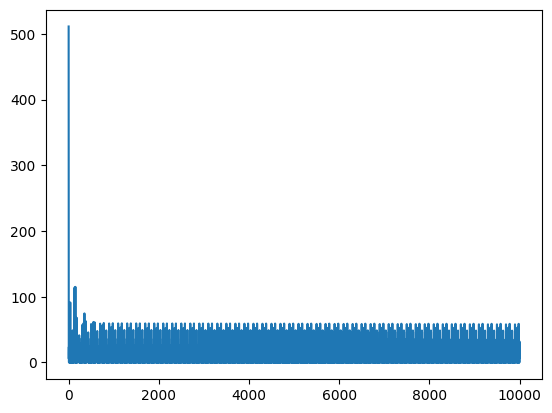

In [ ]:
plt.plot(losses)
plt.show()

In [ ]:
# given new data
tv = 19.2
radio = 35.9
newspaper = 51.3

sales = predict(tv, radio, newspaper, w1, w2, w3, b)
print(f'predicted sales is {sales}')

predicted sales is 8.213399028386949
